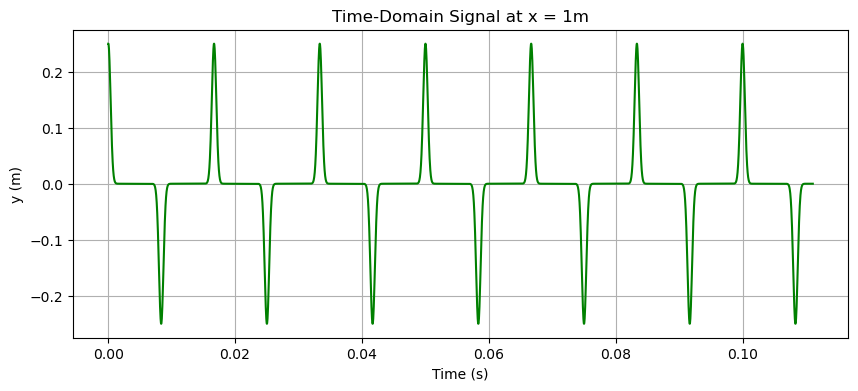

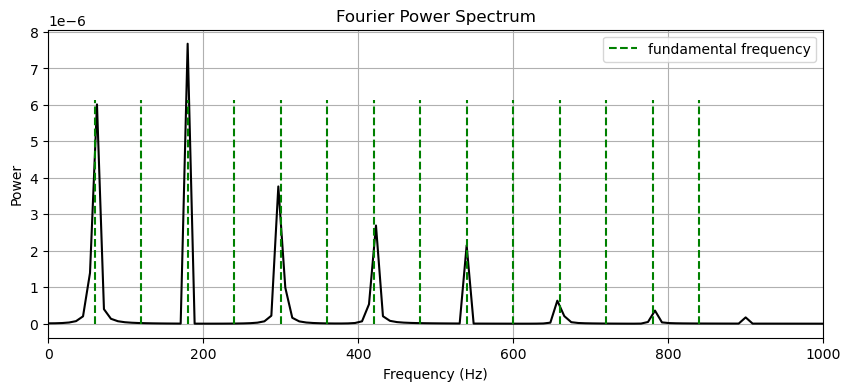

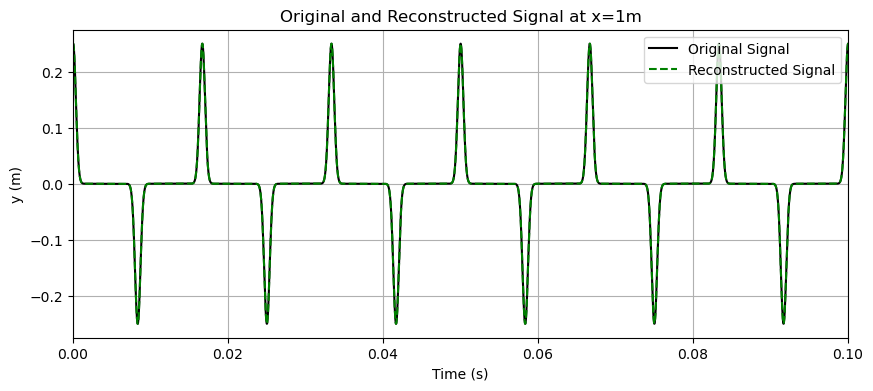

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

def plotReconstructedSignal(inputFile):
    dataFrame = pd.read_csv(inputFile)
    timeVals = dataFrame['time'].values
    origVals = dataFrame[dataFrame.columns[1]].values
    reconVals = dataFrame[dataFrame.columns[2]].values
    plt.figure(figsize=(10, 4))
    plt.plot(timeVals, origVals, color='black', label="Original Signal")
    plt.plot(timeVals, reconVals, color='green', linestyle='--', label="Reconstructed Signal")
    plt.xlabel("Time (s)")
    plt.ylabel("y (m)")
    plt.title("Original and Reconstructed Signal at x=1m")
    plt.xlim(0, 0.1)
    plt.grid(True)
    plt.legend()
    plt.savefig("reconstruction_plot.png")
    plt.show()

def plotTimeSignal(inputFile):
    dataFrame = pd.read_csv(inputFile)
    timeVals = dataFrame['time'].values
    dispVals = dataFrame[dataFrame.columns[1]].values
    plt.figure(figsize=(10, 4))
    plt.plot(timeVals, dispVals, color='green')
    plt.xlabel("Time (s)")
    plt.ylabel("y (m)")
    plt.title("Time-Domain Signal at x = 1m")
    plt.grid(True)
    plt.savefig("time_signal_plot.png")
    plt.show()

def plotPowerSpectrum(inputFile):
    lengthVal = 2.0
    tensionVal = 720.0
    massVal = 0.025
    muVal = massVal / lengthVal
    speedVal = np.sqrt(tensionVal / muVal)
    baseFreq = speedVal / (2 * lengthVal)
    maxHarm = 15
    dataFrame = pd.read_csv(inputFile)
    freqVals = dataFrame['frequency'].values
    powVals = dataFrame[dataFrame.columns[1]].values
    plt.figure(figsize=(10, 4))
    plt.plot(freqVals, powVals, color='black')
    freqLimit = baseFreq * maxHarm
    powMax = 0.8 * np.max(powVals)
    for nVal in range(1, maxHarm + 1):
        harmVal = baseFreq * nVal
        if harmVal < freqLimit:
            plt.plot([harmVal, harmVal], [0, powMax], 'g--', label="fundamental frequency" if nVal == 1 else "")
        else:
            break
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.title("Fourier Power Spectrum")
    plt.grid(True)
    plt.xlim(0, 1000)
    plt.legend()
    plt.savefig("power_spectrum_plot.png")
    plt.show()

def main():
    plotTimeSignal("time_signal.csv")
    plotPowerSpectrum("power_spectrum.csv")
    plotReconstructedSignal("reconstruction.csv")

if __name__ == "__main__":
    main()
